In [1]:
import sys

assert sys.version_info >= (3, 10)

In [2]:
import torch
from packaging.version import Version

assert Version(torch.__version__) >= Version("2.6.0")

In [5]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [7]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "6_poissonequn_with_periodicbc"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, fig_extension="png", tight_layout=True, resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)



In [8]:
import deepxde as dde
from deepxde import utils
import numpy as np

dde.config.set_random_seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [9]:
dde.config.set_default_float("float64")
print(f"Backend: {dde.backend.backend_name}")

Set the default float type to float64
Backend: pytorch


Define exact solution for validation
    Since the sine function will be same for -1 and 1  in the opp direction we will be using sine function for this periodic bc, that satisfies the basic thing for using a periodic bc

In [10]:
def exact_solution(x):
    return np.sin(np.pi * x)

In [14]:
geom = dde.geometry.Interval(-1, 1)


Define the differential equation and boundary conditions

In [15]:
def pde(x, y):
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    return dy_xx + torch.pi**2 * torch.sin(torch.pi * x)


Now define the left (Dirichlet) and right (Periodic) boundary conditions

In [20]:
def boundary_left(x, on_boundary):
    return on_boundary and np.isclose(x[0], -1)

bc_left = dde.icbc.DirichletBC(geom, lambda x: 0, boundary_left)

def boundary_periodic(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[0], 1.0)

bc_periodic_value = dde.icbc.PeriodicBC(
    geom, 0, boundary_periodic, derivative_order=0
)
bc_periodic_derivative = dde.icbc.PeriodicBC(
    geom, 0, boundary_periodic, derivative_order=1
)
bcs = [bc_periodic_value, bc_periodic_derivative]

creating the training data

In [21]:
observe_x = np.linspace(-1, 1, 35).reshape(-1, 1)
observe_y = exact_solution(observe_x)
noise  = 0.05 * np.random.randn(35, 1)
observe_y = observe_y + noise
observe  = dde.icbc.PointSetBC(observe_x, observe_y, component=0)

combining all the data

In [22]:
data = dde.data.PDE(
    geom, pde, [bc_left] + bcs + [observe],
    num_domain=3000, num_boundary=200,
    num_test= 500, anchors=observe_x
)

In [25]:
net = dde.nn.FNN([1, 256, 128, 64, 1], "tanh", "Glorot uniform")
model = dde.Model(data, net)

In [27]:
loss_weights = [1.0, 40.0, 40.0, 40.0, 500.0]

In [28]:
print("\nStage 1: Adam Optimizer")
model.compile("adam", lr=0.001, loss_weights=loss_weights,
              decay=("inverse time", 1000, 0.1))
losshistory, train_state = model.train(iterations=4000, display_every=500)

dde.optimizers.config.set_LBFGS_options(maxiter=200)
model.compile("L-BFGS", loss_weights = loss_weights)
losshistory, train_state = model.train(display_every=50)


Stage 1: Adam Optimizer
Compiling model...
'compile' took 1.775507 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [4.57e+01, 6.66e-01, 2.67e+00, 0.00e+00, 2.93e+02]    [4.89e+01, 6.66e-01, 2.67e+00, 0.00e+00, 2.93e+02]    []  
500       [2.23e-01, 1.13e-02, 1.42e-02, 8.91e-08, 8.75e-01]    [1.11e-01, 1.13e-02, 1.42e-02, 8.91e-08, 8.75e-01]    []  
1000      [1.35e-01, 9.10e-03, 1.05e-02, 2.27e-05, 8.85e-01]    [7.56e-02, 9.10e-03, 1.05e-02, 2.27e-05, 8.85e-01]    []  
1500      [6.37e-02, 1.14e-04, 1.54e-03, 1.82e-02, 1.05e+00]    [3.47e-02, 1.14e-04, 1.54e-03, 1.82e-02, 1.05e+00]    []  
2000      [3.65e-02, 8.59e-03, 9.53e-03, 7.79e-05, 8.78e-01]    [1.90e-02, 8.59e-03, 9.53e-03, 7.79e-05, 8.78e-01]    []  
2500      [2.77e-02, 8.45e-03, 8.01e-03, 1.61e-05, 8.71e-01]    [1.85e-02, 8.45e-03, 8.01e-03, 1.61e-05, 8.71e-01]    []  
3000      [2.59e-02, 8.46e-03, 7.84e-03, 1

Evaluating the results

In [29]:
test_points = 15
x_test = np.linspace(-1, 1, test_points).reshape(-1, 1)
y_pred = model.predict(x_test)
y_exact = exact_solution(x_test)
noise = 0.05 * np.random.randn(15, 1)   # 5% noise
y_test = y_exact + noise

Calculating the errors

In [31]:
absolute_error = np.abs(y_test - y_pred)
relative_error = absolute_error / (np.abs(y_test) + 1e-10)
l2_error = np.linalg.norm(y_test - y_pred) / np.linalg.norm(y_test)

print("\n" + "="*60)
print("📊 PERFORMANCE METRICS")
print("="*60)
print(f"L2 Relative Error:      {l2_error:.6f}")
print(f"Mean Absolute Error:     {np.mean(absolute_error):.6f}")
print(f"Mean Absolute Relative Error:    {np.mean(relative_error):.6f}")


📊 PERFORMANCE METRICS
L2 Relative Error:      0.060611
Mean Absolute Error:     0.036618
Mean Absolute Relative Error:    0.322454


Periodic error

In [32]:
u_at_minus1 = model.predict(np.array([[-1.0]]))[0, 0]
u_at_plus1 = model.predict(np.array([[1.0]]))[0, 0]

# Check periodic BC: u(-1) should equal u(1)
periodic_error = np.abs(u_at_minus1 - u_at_plus1)

print("\n📍 BOUNDARY CONDITION CHECK")
print("-"*60)
print(f"u(-1) = {u_at_minus1:.6f}  (Target: 0.0)")
print(f"u(1) = {u_at_plus1:.6f}  (Should equal u(-1))")
print(f"Periodic BC error: |u(-1) - u(1)| = {periodic_error:.6f}  (Target: 0.0)")
print("="*60)


📍 BOUNDARY CONDITION CHECK
------------------------------------------------------------
u(-1) = -0.014411  (Target: 0.0)
u(1) = -0.001137  (Should equal u(-1))
Periodic BC error: |u(-1) - u(1)| = 0.013274  (Target: 0.0)


In [35]:
final_train_losses = model.losshistory.loss_train[-1]  
L_pde, L_bc_left, L_periodic_val, L_periodic_der, L_data = final_train_losses

print("\n" + "="*60)
print("📉 FINAL TRAINING LOSSES (Unweighted - REAL values used by DeepXDE)")
print("="*60)
print(f"L_PDE: {L_pde:.6e}")
print(f"L_BC_left: {L_bc_left:.6e}")
print(f"L_periodic_val: {L_periodic_val:.6e}")
print(f"L_periodic_der: {L_periodic_der:.6e}")
print(f"L_data: {L_data:.6e}")


📉 FINAL TRAINING LOSSES (Unweighted - REAL values used by DeepXDE)
L_PDE: 1.096576e-02
L_BC_left: 8.306616e-03
L_periodic_val: 7.047995e-03
L_periodic_der: 1.112082e-05
L_data: 8.622287e-01


Visualisation



💾 Results saved to 'pinn_poisson_results.png'


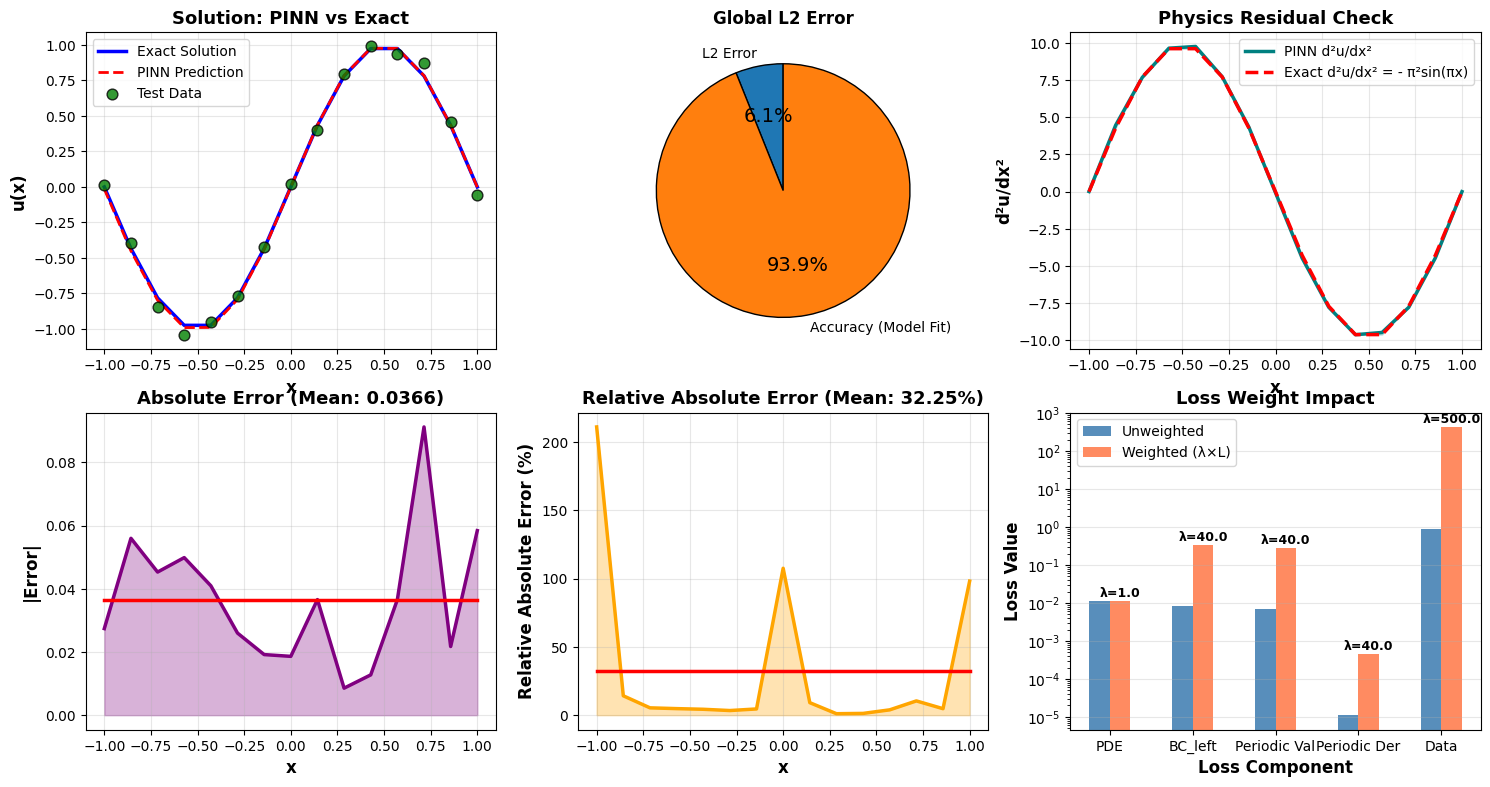

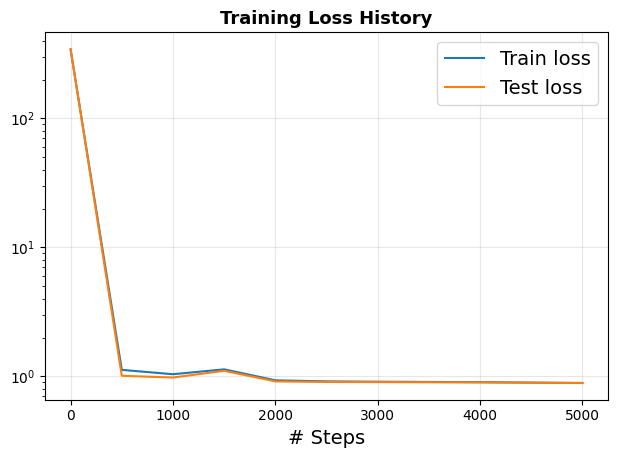

In [37]:
fig = plt.figure(figsize=(18, 14))

# Plot 1: Solution Comparison
ax1 = plt.subplot(3, 3, 1)
plt.plot(x_test, y_exact, 'b-', linewidth=2.5, label='Exact Solution')
plt.plot(x_test, y_pred, 'r--', linewidth=2, label='PINN Prediction')
plt.scatter(x_test, y_test, c='green', s=60, 
            label='Test Data', zorder=5, alpha=0.8, edgecolors='black')
plt.xlabel('x', fontsize=12, fontweight='bold')
plt.ylabel('u(x)', fontsize=12, fontweight='bold')
plt.title('Solution: PINN vs Exact', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)





# -----------------------------------------------
# Plot 2: Global L2 Error Pie Chart
# -----------------------------------------------
ax2 = plt.subplot(3, 3, 2)

# Compute L2 error (%)
l2_error_pct = 100 * np.linalg.norm(y_test - y_pred) / np.linalg.norm(y_test)

# Pie chart values
sizes = [l2_error_pct, 100 - l2_error_pct]
labels = [f'L2 Error', 'Accuracy (Model Fit)']

# Draw pie chart inside subplot
ax2.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'}
)

ax2.set_title('Global L2 Error', fontsize=12, fontweight='bold')

# VERY IMPORTANT so pie fits well inside subplot
ax2.set_aspect('equal')




# Plot 3: Physics Check
ax3 = plt.subplot(3, 3, 3)
d2u_dx2 = model.predict(
    x_test,
    operator=lambda x, y: dde.grad.hessian(y, x, i=0, j=0)
).flatten()  # Flatten and ensure NumPy (post-training, no grad needed)

pde_exact = -np.pi**2 * np.sin(np.pi * x_test)  # Exact d²u/dx²

ax3.plot(x_test, d2u_dx2, 'teal', linewidth=2.5, label='PINN d²u/dx²')
ax3.plot(x_test, pde_exact, 'red', linestyle='--', linewidth=2.5, label='Exact d²u/dx² = - π²sin(πx)')
ax3.fill_between(x_test.flatten(), pde_exact.flatten(), d2u_dx2, alpha=0.2, color='teal')

ax3.set_xlabel('x', fontsize=12, fontweight='bold')
ax3.set_ylabel('d²u/dx²', fontsize=12, fontweight='bold')
ax3.set_title('Physics Residual Check', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)



# Plot 4: Absolute Error
ax4 = plt.subplot(3, 3, 4)

# Absolute error curve
plt.plot(x_test, absolute_error, color='purple', linewidth=2.5)

# Mean absolute error line (constant horizontal line)
mean_abs_err = np.mean(absolute_error)
plt.plot(x_test, np.full_like(x_test, mean_abs_err), color='red', linewidth=2.5)

# Shaded area
plt.fill_between(x_test.flatten(), 0, absolute_error.flatten(), alpha=0.3, color='purple')

# Labels and formatting
plt.xlabel('x', fontsize=12, fontweight='bold')
plt.ylabel('|Error|', fontsize=12, fontweight='bold')
plt.title(f'Absolute Error (Mean: {np.mean(absolute_error):.4f})',
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)





# Plot 5: Relative Absolute Error
ax5 = plt.subplot(3, 3, 5)

# Relative absolute error curve (%)
plt.plot(x_test, relative_error * 100, color='orange', linewidth=2.5)

# Mean relative error line (horizontal)
mean_rel_err_pct = np.mean(relative_error) * 100
plt.plot(x_test, np.full_like(x_test, mean_rel_err_pct), color='red', linewidth=2.5)

# Shaded area
plt.fill_between(x_test.flatten(), 0, (relative_error * 100).flatten(),
                 alpha=0.3, color='orange')

# Labels and formatting
plt.xlabel('x', fontsize=12, fontweight='bold')
plt.ylabel('Relative Absolute Error (%)', fontsize=12, fontweight='bold')
plt.title(f'Relative Absolute Error (Mean: {mean_rel_err_pct:.2f}%)',
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)





# Plot 6: Loss Weight Analysis (Correct & Compact)
ax6 = plt.subplot(3, 3, 6)

# Use actual final training losses from DeepXDE
losses = model.losshistory.loss_train[-1]  # [PDE, BC_left, periodic_val, periodic_der, Data]
weighted = [w * l for w, l in zip(loss_weights, losses)]

components = ['PDE', 'BC_left', 'Periodic Val', 'Periodic Der', 'Data']
x_pos = np.arange(len(components))
width = 0.25  # Narrower for 5 bars

ax6.bar(x_pos - width/2, losses,    width, label='Unweighted', alpha=0.9, color='steelblue')
ax6.bar(x_pos + width/2, weighted,  width, label='Weighted (λ×L)', alpha=0.9, color='coral')

ax6.set_xlabel('Loss Component', fontsize=12, fontweight='bold')
ax6.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
ax6.set_title('Loss Weight Impact', fontsize=13, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(components)
ax6.set_yscale('log')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3, axis='y')

# Annotate λ values on weighted bars
for bar, λ in zip(ax6.patches[len(components):], loss_weights):
    h = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2, h * 1.1, f'λ={λ}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')



# Plot 7: Loss History

dde.utils.plot_loss_history(losshistory)
plt.title('Training Loss History', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)





plt.tight_layout()
plt.savefig('pinn_poisson_results.png', dpi=300, bbox_inches='tight')
print("\n💾 Results saved to 'pinn_poisson_results.png'")
plt.show()